In [2]:
#Osnovne biblioteke

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.ticker import FuncFormatter
from collections import Counter
from scipy.stats import randint
from pathlib import Path


In [3]:
#Scikit-learn – pipeline i transformacije

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    QuantileTransformer,
    FunctionTransformer,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

In [4]:
#Scikit-learn – modeli

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    RidgeCV,
    Lasso,
    ElasticNet
)
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor
)
from sklearn.neural_network import MLPRegressor

In [5]:
#Scikit-learn – evaluacija, metrika i 

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_squared_log_error,
    make_scorer
)
from sklearn.inspection import permutation_importance

In [6]:
#Boosting modeli

import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [7]:
current_directory = str(Path.cwd())
print(current_directory)

C:\Users\aleks\Sberbank\Sberbank-House-Pricing


In [8]:
data = pd.read_csv(current_directory+"/train.csv")
df = pd.DataFrame(data)
pd.set_option('display.max_columns', 300)
pd.set_option('display.max_rows', 300)

In [9]:
df.head()

,id,timestamp,full_sq,life_sq,floor,max_floor,material,build_year,num_room,kitch_sq,state,product_type,sub_area,area_m,raion_popul,green_zone_part,indust_part,children_preschool,preschool_quota,preschool_education_centers_raion,children_school,school_quota,school_education_centers_raion,school_education_centers_top_20_raion,hospital_beds_raion,healthcare_centers_raion,university_top_20_raion,sport_objects_raion,additional_education_raion,culture_objects_top_25,culture_objects_top_25_raion,shopping_centers_raion,office_raion,thermal_power_plant_raion,incineration_raion,oil_chemistry_raion,radiation_raion,railroad_terminal_raion,big_market_raion,nuclear_reactor_raion,detention_facility_raion,full_all,male_f,female_f,young_all,young_male,young_female,work_all,work_male,work_female,ekder_all,ekder_male,ekder_female,0_6_all,0_6_male,0_6_female,7_14_all,7_14_male,7_14_female,0_17_all,0_17_male,0_17_female,16_29_all,16_29_male,16_29_female,0_13_all,0_13_male,0_13_female,raion_build_count_with_material_info,build_count_block,build_count_wood,build_count_frame,build_count_brick,build_count_monolith,build_count_panel,build_count_foam,build_count_slag,build_count_mix,raion_build_count_with_builddate_info,build_count_before_1920,build_count_1921-1945,build_count_1946-1970,build_count_1971-1995,build_count_after_1995,ID_metro,metro_min_avto,metro_km_avto,metro_min_walk,metro_km_walk,kindergarten_km,school_km,park_km,green_zone_km,industrial_km,water_treatment_km,cemetery_km,incineration_km,railroad_station_walk_km,railroad_station_walk_min,ID_railroad_station_walk,railroad_station_avto_km,railroad_station_avto_min,ID_railroad_station_avto,public_transport_station_km,public_transport_station_min_walk,water_km,water_1line,mkad_km,ttk_km,sadovoe_km,bulvar_ring_km,kremlin_km,big_road1_km,ID_big_road1,big_road1_1line,big_road2_km,ID_big_road2,railroad_km,railroad_1line,zd_vokzaly_avto_km,ID_railroad_terminal,bus_terminal_avto_km,ID_bus_terminal,oil_chemistry_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,big_market_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,hospice_morgue_km,detention_facility_km,public_healthcare_km,university_km,workplaces_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,church_synagogue_km,mosque_km,theater_km,museum_km,exhibition_km,catering_km,ecology,green_part_500,prom_part_500,office_count_500,office_sqm_500,trc_count_500,trc_sqm_500,cafe_count_500,cafe_sum_500_min_price_avg,cafe_sum_500_max_price_avg,cafe_avg_price_500,cafe_count_500_na_price,cafe_count_500_price_500,cafe_count_500_price_1000,cafe_count_500_price_1500,cafe_count_500_price_2500,cafe_count_500_price_4000,cafe_count_500_price_high,big_church_count_500,church_count_500,mosque_count_500,leisure_count_500,sport_count_500,market_count_500,green_part_1000,prom_part_1000,office_count_1000,office_sqm_1000,trc_count_1000,trc_sqm_1000,cafe_count_1000,cafe_sum_1000_min_price_avg,cafe_sum_1000_max_price_avg,cafe_avg_price_1000,cafe_count_1000_na_price,cafe_count_1000_price_500,cafe_count_1000_price_1000,cafe_count_1000_price_1500,cafe_count_1000_price_2500,cafe_count_1000_price_4000,cafe_count_1000_price_high,big_church_count_1000,church_count_1000,mosque_count_1000,leisure_count_1000,sport_count_1000,market_count_1000,green_part_1500,prom_part_1500,office_count_1500,office_sqm_1500,trc_count_1500,trc_sqm_1500,cafe_count_1500,cafe_sum_1500_min_price_avg,cafe_sum_1500_max_price_avg,cafe_avg_price_1500,cafe_count_1500_na_price,cafe_count_1500_price_500,cafe_count_1500_price_1000,cafe_count_1500_price_1500,cafe_count_1500_price_2500,cafe_count_1500_price_4000,cafe_count_1500_price_high,big_church_count_1500,church_count_1500,mosque_count_1500,leisure_count_1500,sport_count_1500,market_count_1500,green_part_2000,prom_part_2000,office_count_2000,office_sqm_2000,trc_count_2000,trc_sqm_2000,cafe_count_2000,cafe_sum_2000_min_price_avg,cafe_sum_2000_max_price_av

In [10]:
print(df.dtypes.unique())

[dtype('int64') dtype('O') dtype('float64')]


In [11]:
df.drop(columns=['id'], inplace=True)

In [12]:
df.shape

(30471, 291)

In [13]:
# prag za periferiju (npr. stanovi dalje od 30 km od Kremlja)
df = df[df["kremlin_km"] <= 30].copy()

In [14]:
target = df["price_doc"]
print(target.isna().sum())

0


In [15]:
print(df["price_doc"].head())
print(df["price_doc"].min(), df["price_doc"].max())

0     5850000
1     6000000
2     5700000
3    13100000
4    16331452
Name: price_doc, dtype: int64
100000 111111112


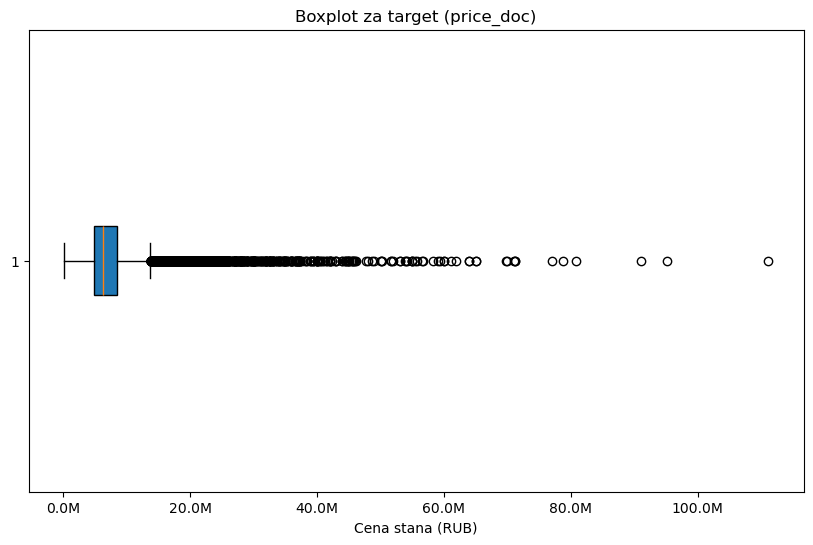

In [16]:

plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

In [17]:
df = df.sample(n=10000, random_state=42)

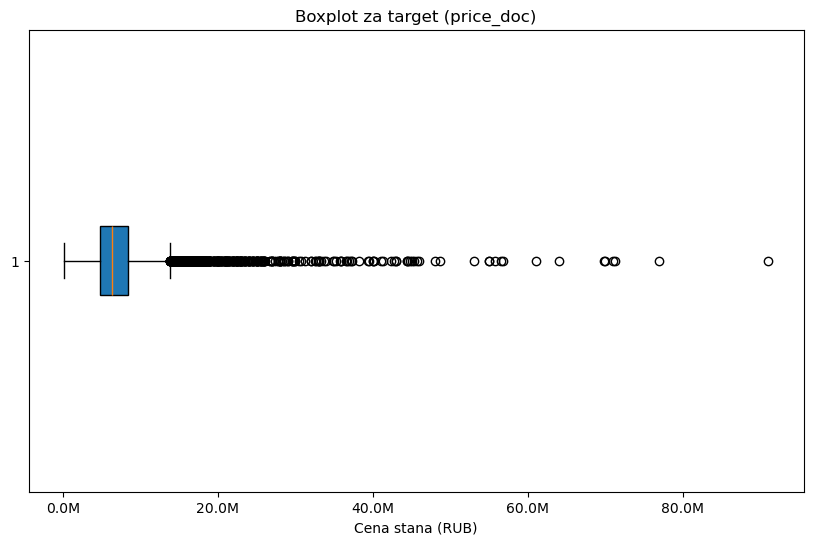

In [18]:
plt.figure(figsize=(10,6))
plt.boxplot(df["price_doc"], vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc)")
plt.xlabel("Cena stana (RUB)")
plt.show()

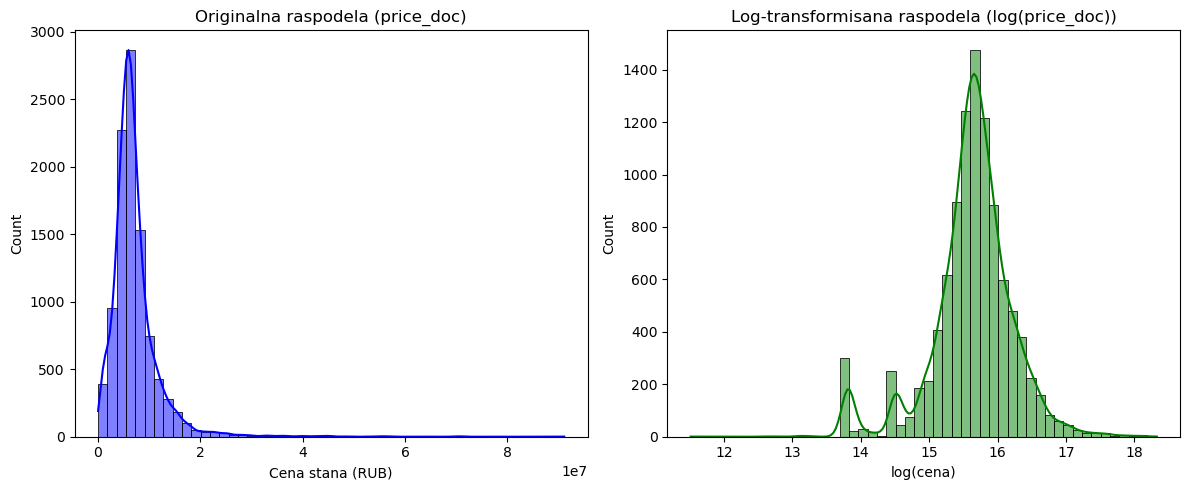

In [19]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["price_doc"], kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(df["price_doc"]), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [20]:
new_cols = []

In [21]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
start = df["timestamp"].min()

df["year"] = df["timestamp"].dt.year
df["month"] = df["timestamp"].dt.month

df.drop(columns=['timestamp'], inplace=True)
new_cols.extend(["year","month"])

In [22]:
df.shape

(10000, 292)

In [23]:
df["floor_ratio"] = df.apply(
    lambda row: row["floor"] / row["max_floor"] if pd.notnull(row["max_floor"]) and row["max_floor"] > 0 else 0,
    axis=1
)

In [24]:
df["build_age"] = df["year"] - df["build_year"]
new_cols.extend(["floor_ratio","build_age"])

In [25]:
df.shape

(10000, 294)

In [26]:
cols = [c for c in df.columns if c != 'price_doc'] + ['price_doc']
df = df[cols]

In [27]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [28]:
print(y.name)

price_doc


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
y_train.head()

10907    5073100
5427     3180200
7500     4000000
29721    5113544
11861    5425062
Name: price_doc, dtype: int64

In [311]:
"""Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = (y_train >= lower_bound) & (y_train <= upper_bound)

X_train = X_train.loc[mask]
y_train = y_train.loc[mask]"""

lower = y_train.quantile(0.12)
upper = y_train.quantile(0.9)

mask = (y_train >= lower) & (y_train <= upper)

X_train_clean = X_train.loc[mask]
y_train_clean = y_train.loc[mask]

In [319]:
print(y_train.isna().sum().sum())
print(y_test.isna().sum().sum())

0
0


In [315]:
df = df.dropna(subset=["price_doc"]).copy()

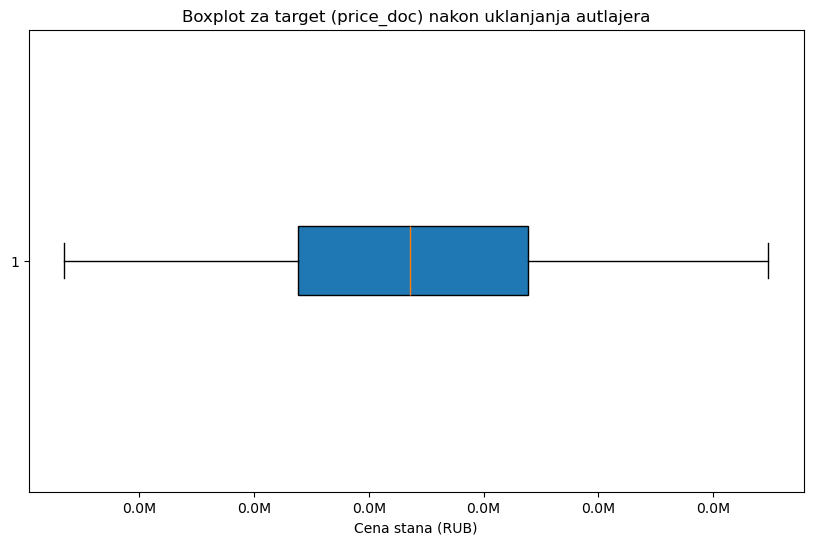

In [316]:
plt.figure(figsize=(10,6))
plt.boxplot(y_train_clean, vert=False, patch_artist=True)

plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.title("Boxplot za target (price_doc) nakon uklanjanja autlajera")
plt.xlabel("Cena stana (RUB)")
plt.show()

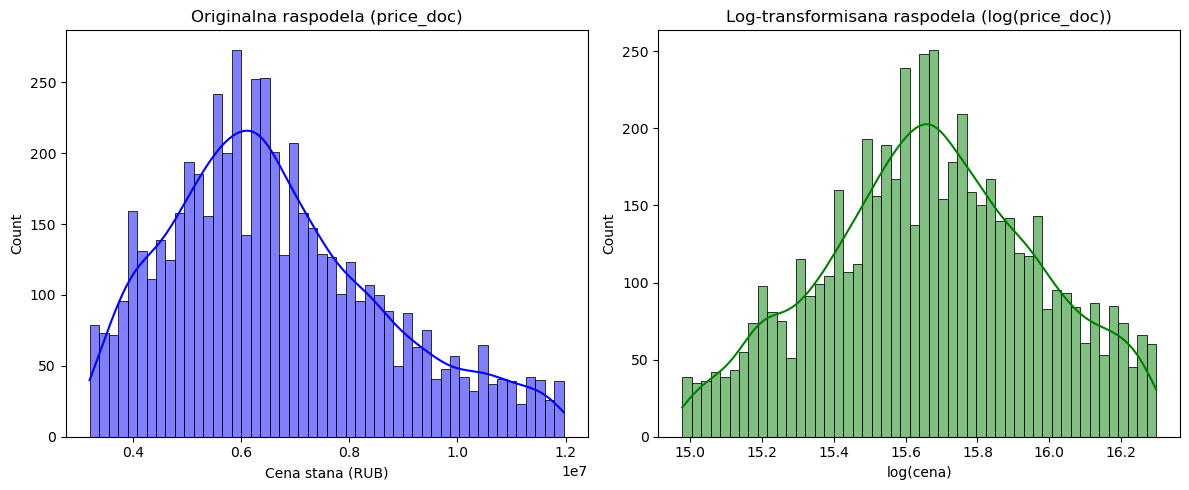

In [35]:
# originalni target
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(y_train_clean, kde=True, bins=50, color="blue")
plt.title("Originalna raspodela (price_doc)")
plt.xlabel("Cena stana (RUB)")

# log-transformisani target
plt.subplot(1,2,2)
sns.histplot(np.log1p(y_train_clean), kde=True, bins=50, color="green")
plt.title("Log-transformisana raspodela (log(price_doc))")
plt.xlabel("log(cena)")

plt.tight_layout()
plt.show()

In [36]:
df["price_doc_log"] = np.log1p(df["price_doc"])

In [37]:
y_train_clean = np.log1p(y_train_clean)

### Test

In [39]:
def missing_values_ratio(df, ratio_for_na_values=0.3, target_col="price_doc", corr_threshold=0.4):

    missing_ratio = df.isnull().mean().sort_values(ascending=False)
    
    cols_over_n = missing_ratio[missing_ratio > ratio_for_na_values]
    cols_to_drop = []
    
    if not cols_over_n.empty:
        print(f"Kolone sa preko {round(ratio_for_na_values*100)}% nedostajućih vrednosti:\n")
        
        for col in cols_over_n.index:
            if df[col].dtype in ['int64', 'float64']:  
                corr_val = df[[col, target_col]].corr().iloc[0, 1]  
                if (corr_val is None) or (abs(corr_val) < corr_threshold):
                    cols_to_drop.append(col)
                print(f"{col}: {cols_over_n[col]*100:.2f}% NaN, korelacija sa targetom = {corr_val:.3f}")
        return cols_to_drop
    else:
        print("Nema takvih kolona")
        return []

In [40]:
columns_to_drop = missing_values_ratio(df, 0.3, "price_doc", 0.4)

Kolone sa preko 30% nedostajućih vrednosti:

hospital_beds_raion: 46.40% NaN, korelacija sa targetom = 0.134
build_year: 44.68% NaN, korelacija sa targetom = 0.003
build_age: 44.68% NaN, korelacija sa targetom = -0.003
state: 44.56% NaN, korelacija sa targetom = 0.128
cafe_sum_500_min_price_avg: 41.95% NaN, korelacija sa targetom = 0.040
cafe_avg_price_500: 41.95% NaN, korelacija sa targetom = 0.040
cafe_sum_500_max_price_avg: 41.95% NaN, korelacija sa targetom = 0.040
max_floor: 31.84% NaN, korelacija sa targetom = 0.072
material: 31.84% NaN, korelacija sa targetom = 0.058
num_room: 31.84% NaN, korelacija sa targetom = 0.492
kitch_sq: 31.84% NaN, korelacija sa targetom = 0.022


In [41]:
print(len(X_test.columns.tolist()))

293


In [42]:
X_test = X_test.drop(columns=columns_to_drop)  
X_train = X_train_clean.drop(columns=columns_to_drop) 

In [43]:
X_train.shape, X_test.shape

((5600, 283), (3000, 283))

In [44]:
train_imputer = SimpleImputer

In [45]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

In [46]:
train_num = X_train[num_cols].copy()
train_cat = X_train[cat_cols].copy()

In [47]:
train_num.shape, train_cat.shape

((5600, 266), (5600, 15))

In [48]:
for cat in cat_cols:
    print(cat)
    print(train_cat[cat].unique())

product_type
['OwnerOccupier' 'Investment']
sub_area
['Nekrasovka' 'Otradnoe' 'Poselenie Desjonovskoe' 'Poselenie Moskovskij'
 'Poselenie Shherbinka' 'Perovo' 'Dmitrovskoe' 'Mitino' 'Rjazanskij'
 'Lefortovo' 'Hovrino' 'Tverskoe' 'Severnoe Tushino' 'Jaroslavskoe'
 "Kon'kovo" 'Poselenie Sosenskoe' "Gol'janovo" "Mar'ino" 'Teplyj Stan'
 'Butyrskoe' 'Zjablikovo' 'Begovoe' 'Juzhnoe Butovo'
 'Poselenie Voskresenskoe' 'Koptevo' 'Fili Davydkovo' 'Krylatskoe'
 'Ochakovo-Matveevskoe' 'Troparevo-Nikulino' 'Ivanovskoe' 'Kuncevo'
 'Orehovo-Borisovo Juzhnoe' 'Poselenie Vnukovskoe' 'Nagatino-Sadovniki'
 'Poselenie Filimonkovskoe' 'Zapadnoe Degunino' 'Strogino'
 'Juzhnoe Medvedkovo' 'Obruchevskoe' 'Jasenevo' 'Severnoe Medvedkovo'
 'Shhukino' "Altuf'evskoe" 'Novo-Peredelkino' 'Juzhnoportovoe'
 'Dorogomilovo' "Tekstil'shhiki" 'Timirjazevskoe'
 'Orehovo-Borisovo Severnoe' 'Alekseevskoe' 'Presnenskoe'
 'Birjulevo Zapadnoe' 'Izmajlovo' 'Nagatinskij Zaton' 'Golovinskoe'
 'Bibirevo' 'Sokolinaja Gora' 'Basmann

In [49]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]

In [50]:
print(nominal_cols)

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [51]:
train_cat["ecology"] = train_cat["ecology"].replace("no data", np.nan)
train_cat = train_cat.replace(["nan", "NaN", ""], np.nan)
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
train_cat = imputer.fit_transform(train_cat)

In [52]:
train_cat.isna().sum().sum()

0

In [53]:
imputer_num = SimpleImputer(strategy="median").set_output(transform="pandas")
train_num = imputer.fit_transform(train_num)

train_num.isna().sum().sum()

0

In [54]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X

In [55]:
def categorical_to_numeric(df_obj, nominal_cols, ordinal_cols, freq_cols):
    if freq_cols:
        fe = FrequencyEncoder(columns=freq_cols, normalize=True)
        df_obj[freq_cols] = fe.fit_transform(df_obj[freq_cols])


    if nominal_cols:
        ohe = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")
        df_encoded = pd.DataFrame(
            ohe.fit_transform(df_obj[nominal_cols]),
            columns=ohe.get_feature_names_out(nominal_cols),
            index=df_obj.index
        )
        df_obj = df_obj.drop(columns=nominal_cols)
        df_obj = pd.concat([df_obj, df_encoded], axis=1)

    if ordinal_cols:
        order = [["excellent", "good", "satisfactory", "poor"]]
        enc = OrdinalEncoder(categories=order)
        for col in ordinal_cols:
            df_obj[col] = enc.fit_transform(df_obj[[col]])

    return df_obj

In [56]:
train_cat_to_num = categorical_to_numeric(train_cat, nominal_cols, ordinal_cols, freq_cols)

In [57]:
train_cat_to_num.shape

(5600, 15)

In [58]:
train_cat_with_target = train_cat_to_num.copy()
train_cat_with_target['price_doc'] = y_train 

corr = train_cat_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.25) | (corr <= -0.25)])

price_doc                     1.000000
product_type_OwnerOccupier   -0.305960
sub_area                     -0.313614
Name: price_doc, dtype: float64


In [59]:
def columns_selector(train_num_with_target, corr_treshold = 0.25):
    
    corr_matrix = train_num_with_target.corr(numeric_only=True)
    target_corr = corr_matrix["price_doc"].drop("price_doc")
    selected_features = target_corr[target_corr.abs() > corr_treshold].index.tolist()
    
    print(f"Feature-i sa korelacijom > {corr_treshold} sa targetom:")
    print(selected_features)

    return selected_features

Feature-i sa korelacijom > 0.11 sa targetom:
['sub_area', 'ecology', 'product_type_OwnerOccupier', 'incineration_raion_yes', 'radiation_raion_yes', 'big_market_raion_yes']


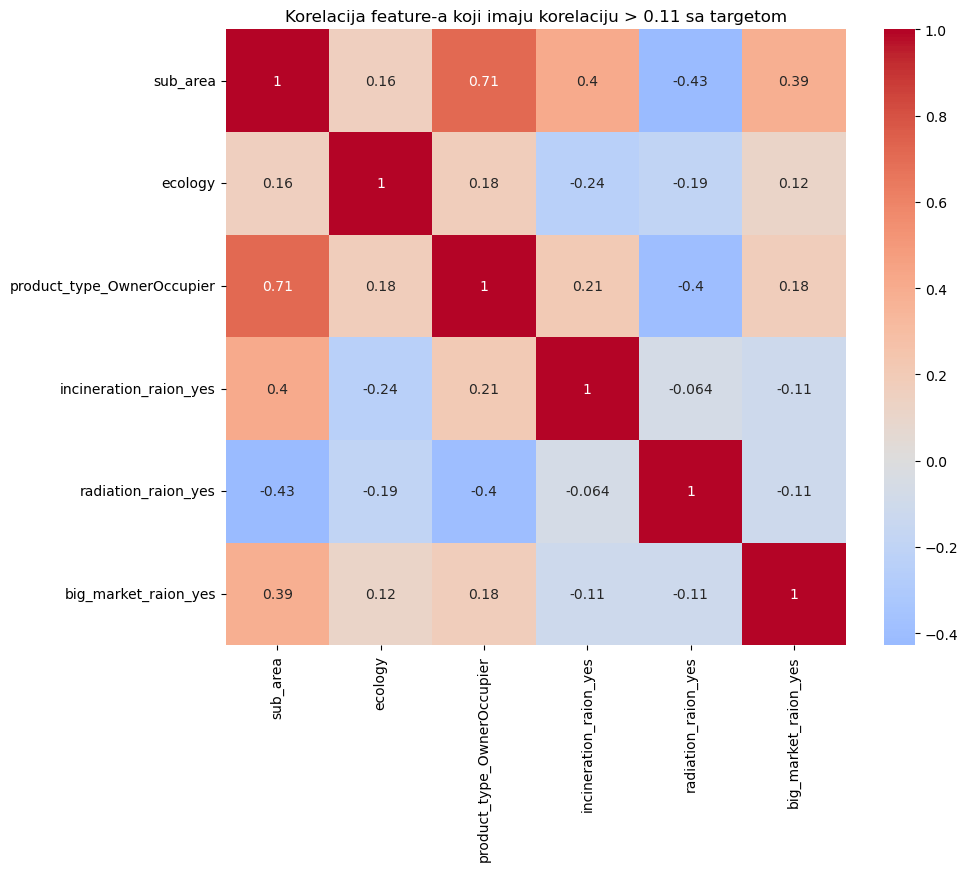

In [60]:
corr_treshold = 0.11
selected_features = columns_selector(train_cat_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_cat_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [61]:
train_cat_to_num.head()

,sub_area,ecology,product_type_OwnerOccupier,culture_objects_top_25_yes,thermal_power_plant_raion_yes,incineration_raion_yes,oil_chemistry_raion_yes,radiation_raion_yes,railroad_terminal_raion_yes,big_market_raion_yes,nuclear_reactor_raion_yes,detention_facility_raion_yes,water_1line_yes,big_road1_1line_yes,railroad_1line_yes
10907,0.068929,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7500,0.011429,3.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29721,0.011786,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11861,0.038036,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5502,0.015714,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
train_num_with_target = train_num.copy()
train_num_with_target['price_doc'] = y_train 

corr = train_num_with_target.corr()["price_doc"].sort_values(ascending=False)
print(corr[(corr >= 0.2) | (corr <= -0.2)])

price_doc                            1.000000
num_room                             0.401546
full_sq                              0.368561
ekder_male                           0.341923
ekder_all                            0.338440
work_male                            0.338294
raion_popul                          0.336572
ekder_female                         0.335362
work_all                             0.332894
work_female                          0.325797
0_17_all                             0.310868
0_17_male                            0.310673
0_17_female                          0.310565
young_female                         0.308700
young_all                            0.308549
7_14_male                            0.308422
0_13_female                          0.308400
0_13_all                             0.308287
0_6_female                           0.308200
7_14_all                             0.307942
children_school                      0.307942
young_male                        

In [ ]:
corr_treshold = 0.25

selected_features = columns_selector(train_num_with_target, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(train_num_with_target[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

In [64]:
def drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.85):

    corr_matrix = train_num_with_target[selected_features].corr()
    
    df_cleared = train_num_with_target[selected_features]
    
    target_corr = df_cleared.corrwith(y_train).abs()
    
    high_corr_pairs = [
        (col1, col2)
        for col1 in corr_matrix.columns
        for col2 in corr_matrix.columns
        if col1 < col2 and corr_matrix.loc[col1, col2] > pairs_treshold
    ]
    
    print(high_corr_pairs)
    print(f"len: {len(high_corr_pairs)}")
    print()
    print("col1 to col2 ratio")
    print()
    cols_to_drop = []
    
    for c1, c2 in high_corr_pairs:
        if target_corr.get(c1, 0) < target_corr.get(c2, 0):
            print(f"{c1} < {c2}  :  {target_corr.get(c1, 0)} < {target_corr.get(c2, 0)}")
            cols_to_drop.append(c2)
        else:
            print(f"{c2} < {c1}  :  {target_corr.get(c2, 0)} < {target_corr.get(c1, 0)}")       
            cols_to_drop.append(c1)
    
    df_cleared = df_cleared.drop(columns=cols_to_drop)
    print()
    print("columns to keep :")
    print(df_cleared.columns)
    print(f"len: {len(df_cleared.columns)}")

    return df_cleared

In [65]:
df_cleared = drop_hight_corr_pairs(train_num_with_target, selected_features, pairs_treshold=0.9)
df_cleared.head()

[('raion_popul', 'young_all'), ('raion_popul', 'young_male'), ('raion_popul', 'young_female'), ('raion_popul', 'work_all'), ('raion_popul', 'work_male'), ('raion_popul', 'work_female'), ('children_preschool', 'raion_popul'), ('children_preschool', 'children_school'), ('children_preschool', 'young_all'), ('children_preschool', 'young_male'), ('children_preschool', 'young_female'), ('children_preschool', 'work_all'), ('children_preschool', 'work_male'), ('children_preschool', 'work_female'), ('preschool_education_centers_raion', 'school_education_centers_raion'), ('children_school', 'raion_popul'), ('children_school', 'young_all'), ('children_school', 'young_male'), ('children_school', 'young_female'), ('children_school', 'work_all'), ('children_school', 'work_male'), ('children_school', 'work_female'), ('young_all', 'young_male'), ('young_all', 'young_female'), ('young_female', 'young_male'), ('work_all', 'young_all'), ('work_all', 'young_male'), ('work_all', 'young_female'), ('work_all

,full_sq,life_sq,num_room,area_m,preschool_education_centers_raion,healthcare_centers_raion,sport_objects_raion,shopping_centers_raion,0_6_male,build_count_panel,build_count_1971-1995,metro_min_avto,kindergarten_km,park_km,railroad_station_avto_km,public_transport_station_km,kremlin_km,big_road2_km,nuclear_reactor_km,radiation_km,power_transmission_line_km,thermal_power_plant_km,ts_km,market_shop_km,fitness_km,swim_pool_km,ice_rink_km,stadium_km,basketball_km,detention_facility_km,public_healthcare_km,university_km,shopping_centers_km,office_km,additional_education_km,preschool_km,big_church_km,theater_km,museum_km,exhibition_km,catering_km,sport_count_1500,trc_count_2000,trc_sqm_3000,market_count_3000,trc_sqm_5000,market_count_5000
10907,52.0,52.0,2.0,1.139168e+07,5.0,0.0,0.0,0.0,862.0,28.0,10.0,4.721045,0.286711,4.616176,1.923495,0.035986,20.549464,2.657336,16.372510,4.317744,6.380918,9.046319,5.013100,5.439734,2.493236,8.106936,8.623789,13.591774,5.211201,12.239172,5.422551,8.837248,2.215104,4.778766,0.203466,0.214197,3.468289,9.836242,7.288785,7.402244,1.836073,0.0,0.0,41100.0,0.0,44437.0,1.0
7500,40.0,21.0,2.0,1.005305e+07,4.0,1.0,10.0,9.0,5044.0,222.0,246.0,1.460105,0.428231,1.260823,3.015990,0.165137,11.471414,4.260110,4.351630,1.456370,1.094540,6.922332,0.657723,1.064877,0.446287,1.184762,2.432869,6.674092,2.573489,4.819273,1.969965,1.231352,0.587646,0.218326,1.023162,0.368795,0.255579,7.021556,3.751794,4.355259,0.311108,9.0,9.0,650998.0,2.0,2483076.0,9.0
29721,68.0,30.0,2.0,5.299528e+07,0.0,0.0,0.0,0.0,495.0,28.0,10.0,15.839451,4.415205,9.684197,21.279217,1.791212,29.133765,9.152001,23.376473,12.721488,9.137023,17.293548,13.011139,7.480514,5.980372,15.850078,16.387081,19.746806,15.523658,37.115402,12.478079,16.569250,7.937008,7.937008,3.978097,7.671322,9.559846,19.307792,18.104218,14.248256,0.046830,0.0,0.0,0.0,0.0,0.0,0.0
11861,62.0,19.0,2.0,4.036700e+07,0.0,0.0,3.0,2.0,777.0,0.0,0.0,8.458554,3.861878,6.520123,8.623783,0.133602,23.373697,6.886762,18.325112,9.301084,5.601574,12.151073,6.009804,9.624964,1.869427,6.507849,6.702009,11.801542,10.566465,30.313039,6.039067,10.796619,0.980817,0.980817,0.594860,3.532680,4.471586,11.362528,11.345507,6.304777,0.537798,0.0,1.0,117300.0,0.0,139300.0,0.0
5502,179.0,178.0,2.0,7.878765e+06,0.0,0.0,0.0,1.0,1065.0,0.0,0.0,9.563829,1.547085,2.402351,2.413475,0.227286,28.378798,4.206688,18.635444,9.987455,7.005131,10.642137,12.507786,2.916401,2.703263,5.398101,13.420050,20.819814,12.577765,26.792674,7.840428,22.660595,0.875766,2.739078,1.428751,3.400250,4.527153,25.399137,15.983514,13.265457,1.323322,0.0,1.0,175000.0,1.0,175000.0,1.0


### 1. Dimenzije i sobe

full_sq → ukupna kvadratura stana (m²).

life_sq → stambena površina stana (m²), dakle samo sobe, bez hodnika, balkona i pomoćnih prostorija.

num_room → broj soba u stanu.

In [67]:
flags = []

In [68]:
def bar_plot(df, col, y_label="price_doc"):
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=40, color="steelblue", edgecolor="black")
    plt.title(f"Distribucija {col}")
    plt.xlabel(col)
    plt.ylabel(y_label)
    plt.show()

def scatter_plot(df, col, target = "price_doc"):
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df[target], alpha=0.3)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

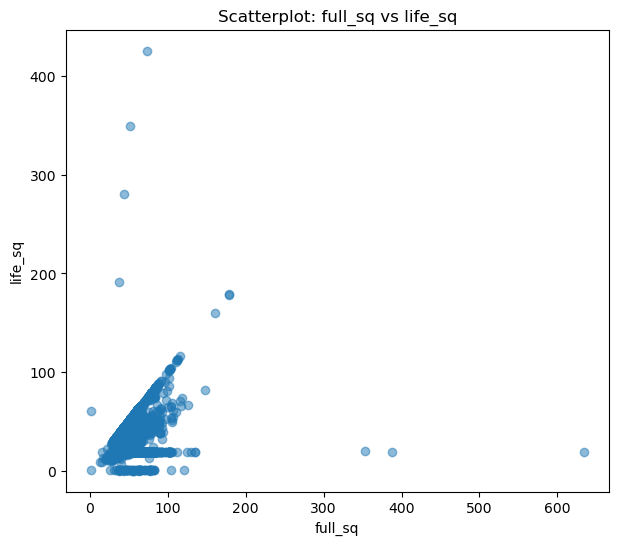

In [69]:
plt.figure(figsize=(7, 6))
plt.scatter(train_num_with_target["full_sq"], train_num_with_target["life_sq"], alpha=0.5)
plt.xlabel("full_sq")
plt.ylabel("life_sq")
plt.title("Scatterplot: full_sq vs life_sq")
plt.show()


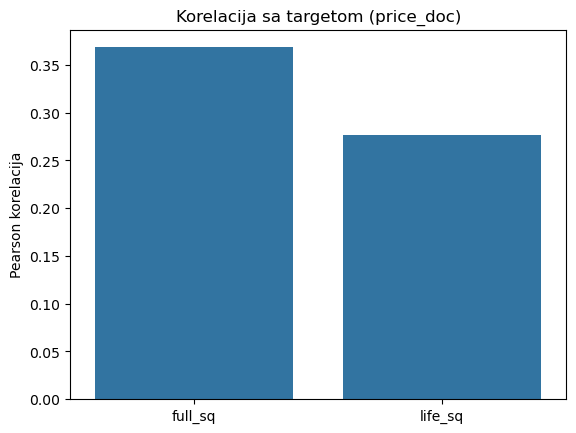

Korelacija full_sq sa targetom: 0.36856121144452064
Korelacija life_sq sa targetom: 0.27643054320818616


In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_full = train_num_with_target["full_sq"].corr(train_num_with_target["price_doc"])
corr_life = train_num_with_target["life_sq"].corr(train_num_with_target["price_doc"])

corr_dict = {
    "full_sq": corr_full,
    "life_sq": corr_life
}

sns.barplot(x=list(corr_dict.keys()), y=list(corr_dict.values()))
plt.title("Korelacija sa targetom (price_doc)")
plt.ylabel("Pearson korelacija")
plt.show()

print("Korelacija full_sq sa targetom:", corr_full)
print("Korelacija life_sq sa targetom:", corr_life)

* Solidna korelacija full_sq i life_sq sa targetom

* Loša međusobna korelacija

* Treba zadržati oba

In [72]:
bad_full = df[df["full_sq"] <= 0]
bad_life = df[df["life_sq"] <= 0]
bad_ratio = df[df["life_sq"] > df["full_sq"]]
bad_room_zero = df[df["num_room"] == 0]
bad_room_high = df[df["num_room"] > 10]
df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)
bad_sqm_low = df[df["sqm_per_room"] < 8]
bad_sqm_high = df[df["sqm_per_room"] > 80]


print("Provera dal postoje stanovi sa kvadraturom < 0")
print("Kvadratura <= 0:", bad_full.shape[0])
print("life_sq <= 0:", bad_life.shape[0])
print("life_sq > full_sq:", bad_ratio.shape[0])
print("num_room = 0:", bad_room_zero.shape[0])
print("num_room > 10:", bad_room_high.shape[0])
print("sqm_per_room < 8:", bad_sqm_low.shape[0])
print("sqm_per_room > 80:", bad_sqm_high.shape[0])

Provera dal postoje stanovi sa kvadraturom < 0
Kvadratura <= 0: 0
life_sq <= 0: 14
life_sq > full_sq: 14
num_room = 0: 4
num_room > 10: 1
sqm_per_room < 8: 11
sqm_per_room > 80: 21


In [73]:
# --- life_sq ---
df["life_sq_missing_or_zero"] = (df["life_sq"] <= 0).astype(int)
df["life_sq_bigger_full"] = (df["life_sq"] > df["full_sq"]).astype(int)


df.loc[df["life_sq"] <= 0, "life_sq"] = np.nan
df.loc[df["life_sq"] > df["full_sq"], "life_sq"] = np.nan

# --- num_room ---
df["num_room_zero"] = (df["num_room"] == 0).astype(int)
df["num_room_outlier"] = (df["num_room"] > 10).astype(int)

df.loc[df["num_room"] == 0, "num_room"] = np.nan
df.loc[df["num_room"] > 10, "num_room"] = np.nan

df["sqm_per_room"] = df["full_sq"] / df["num_room"].replace(0, np.nan)

df["sqm_too_small"] = (df["sqm_per_room"] < 8).astype(int)
df["sqm_too_big"] = (df["sqm_per_room"] > 80).astype(int)

df.loc[df["sqm_per_room"] < 8, "num_room"] = np.nan
df.loc[df["sqm_per_room"] > 80, "num_room"] = np.nan


flags.extend(["life_sq_bigger_full","life_sq_bigger_full","num_room_zero","num_room_outlier","sqm_too_small","sqm_too_big"])
new_cols.extend(["sqm_per_room"])

Poredjenje full_sq sa num_room

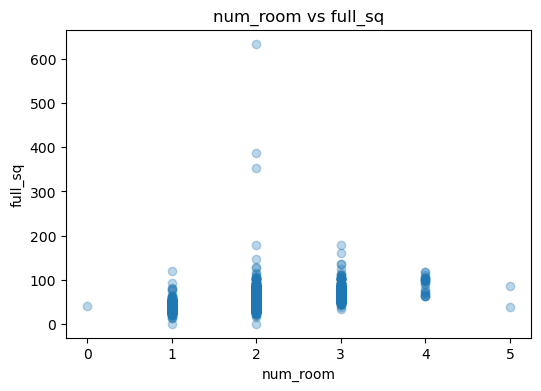

In [75]:
scatter_plot(train_num_with_target, col = "num_room",target="full_sq")

### 2. Saobraćaj i udaljenosti do centra

* metro_min_avto – vreme u minutima do najbliže metro stanice kolima

* kremlin_km – udaljenost u kilometrima do Kremlja

In [77]:
cols = ["metro_min_avto", "kremlin_km"]

print(df[cols].describe())

       metro_min_avto    kremlin_km
count    10000.000000  10000.000000
mean         3.770472     14.793846
std          3.908874      6.564578
min          0.000000      0.072897
25%          1.683219     10.179723
50%          2.677455     14.294238
75%          4.624288     20.360628
max         34.853238     29.877217


In [78]:
cols = ["metro_min_avto", "kremlin_km"]

thresholds = [0, 1, 2, 5, 10, 20, 50, 100]

for col in cols:
    print(f"\n=== {col} ===")
    for t in thresholds:
        count = (df[col] <= t).sum()
        print(f" <= {t}: {count}")



=== metro_min_avto ===
 <= 0: 1
 <= 1: 741
 <= 2: 3327
 <= 5: 7968
 <= 10: 9621
 <= 20: 9920
 <= 50: 10000
 <= 100: 10000

=== kremlin_km ===
 <= 0: 0
 <= 1: 200
 <= 2: 233
 <= 5: 694
 <= 10: 2411
 <= 20: 7399
 <= 50: 10000
 <= 100: 10000


In [79]:
mask = (df["metro_min_avto"] < 0.5) | (df["kremlin_km"] < 0.1)
df.loc[mask, ["metro_min_avto", "kremlin_km"]] = np.nan
df["is_near_kremlin"] = (df["kremlin_km"] < 1).astype(int)
flags.extend(["is_near_kremlin"])

In [80]:
df.loc[mask, ["metro_min_avto", "kremlin_km"]]

,metro_min_avto,kremlin_km
30119,NaN,NaN
9549,NaN,NaN
28357,NaN,NaN
20908,NaN,NaN
15926,NaN,NaN
...,...,...
27417,NaN,NaN
26641,NaN,NaN
25009,NaN,NaN
11625,NaN,NaN


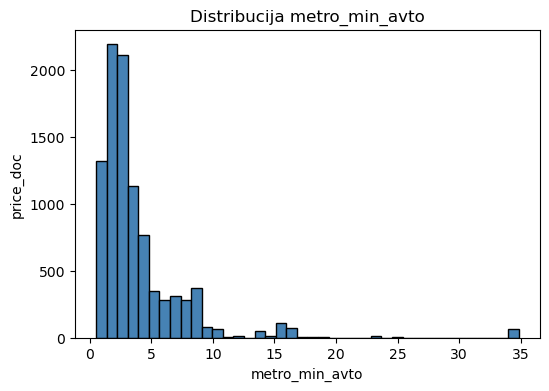

In [81]:
bar_plot(df, col = "metro_min_avto")

In [82]:
df["metro_far"] = (df["metro_min_avto"] > 30).astype(int)
df.loc[df["metro_min_avto"] > 30, "metro_min_avto"] = np.nan
flags.extend(["metro_far"])

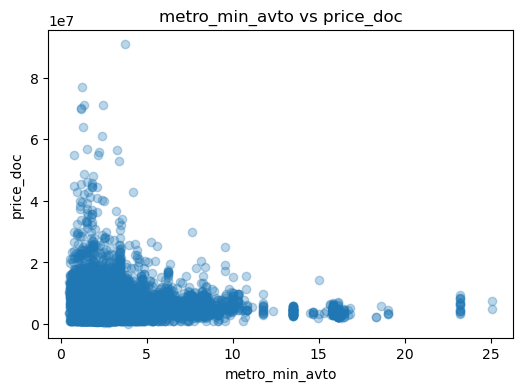

In [83]:
scatter_plot(df, col = "metro_min_avto")

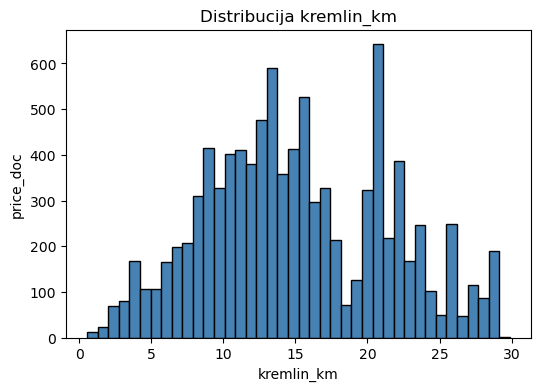

In [84]:
bar_plot(df, col = "kremlin_km")

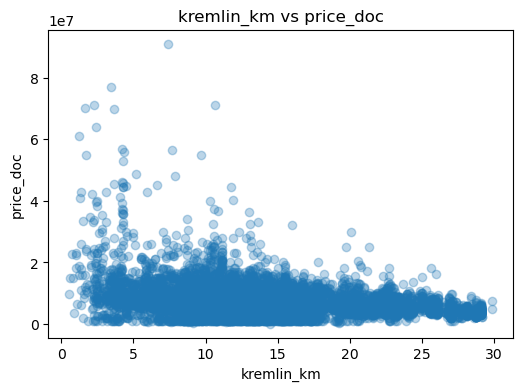

In [85]:
scatter_plot(df, col = "kremlin_km")

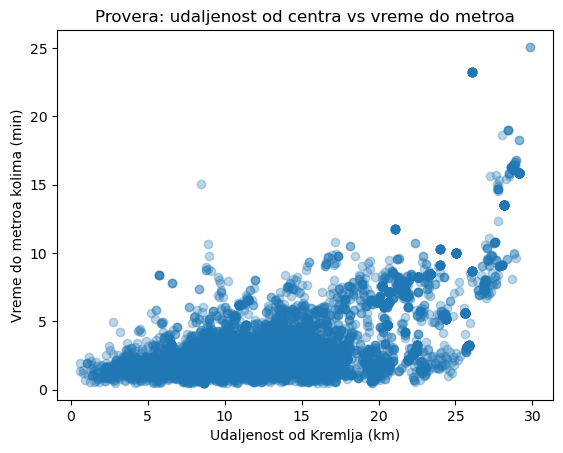

In [86]:
plt.scatter(df["kremlin_km"], df["metro_min_avto"], alpha=0.3)
plt.xlabel("Udaljenost od Kremlja (km)")
plt.ylabel("Vreme do metroa kolima (min)")
plt.title("Provera: udaljenost od centra vs vreme do metroa")
plt.show()

### 3. Okruženje i infrastruktura

* workplaces_km – udaljenost u kilometrima do poslovnih centara

* catering_km – udaljenost u kilometrima do najbližeg restorana ili ketering objekta

* big_church_km – udaljenost u kilometrima do najbliže velike crkve

In [88]:
cols = ["workplaces_km", "catering_km", "big_church_km"]

# pragovi za "previše daleko"
thresholds = {
    "workplaces_km": 50,   # poslovni centri su uglavnom u centru
    "catering_km": 20,     # restorani teško da su preko 20 km daleko
    "big_church_km": 30    # velike crkve obično u gradu
}

for col in cols:
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"> {thresholds[col]} km: {(df[col] > thresholds[col]).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")
    print()

# dodatne neusaglašenosti sa kremlin_km
print("\n=== Neusaglašenosti u odnosu na kremlin_km ===")
print("workplaces dalje od 2x kremlin:", (df["workplaces_km"] > 2 * df["kremlin_km"]).sum())
print("catering dalje od 10 km i kremlin < 5 km:", ((df["catering_km"] > 10) & (df["kremlin_km"] < 5)).sum())
print("big_church dalje od 20 km i kremlin < 5 km:", ((df["big_church_km"] > 20) & (df["kremlin_km"] < 5)).sum())



=== workplaces_km ===
Ukupno vrednosti: 10000
=0: 3
> 50 km: 0
Min: 0.0, Max: 14.43076725


=== catering_km ===
Ukupno vrednosti: 10000
=0: 0
> 20 km: 0
Min: 0.000503046, Max: 4.117323591


=== big_church_km ===
Ukupno vrednosti: 10000
=0: 0
> 30 km: 0
Min: 0.005222257, Max: 10.17103392


=== Neusaglašenosti u odnosu na kremlin_km ===
workplaces dalje od 2x kremlin: 0
catering dalje od 10 km i kremlin < 5 km: 0
big_church dalje od 20 km i kremlin < 5 km: 0


In [89]:
df["workplaces_zero"] = (df["workplaces_km"] == 0).astype(int)
df["workplaces_far"] = (df["workplaces_km"] > 50).astype(int)
df["big_church_far"] = (df["big_church_km"] > 30).astype(int)

df.loc[df["workplaces_km"] == 0, "workplaces_km"] = np.nan
df.loc[df["workplaces_km"] > 50, "workplaces_km"] = np.nan
df.loc[df["big_church_km"] > 30, "big_church_km"] = np.nan

flags.extend(["workplaces_zero","workplaces_far","big_church_far"])

### 4. Posebne lokacije

* nuclear_reactor_km – udaljenost do nuklearnog reaktora

* detention_facility_km – udaljenost do zatvora / pritvorske jedinice


In [91]:
cols = {
    "nuclear_reactor_km": 100,       
    "detention_facility_km": 60      
}

for col, thr in cols.items():
    print(f"\n=== {col} ===")
    print(f"Ukupno vrednosti: {df[col].shape[0]}")
    print(f"=0: {(df[col] == 0).sum()}")
    print(f"<0.1 km: {(df[col] < 0.1).sum()}")   
    print(f"> {thr} km: {(df[col] > thr).sum()}")
    print(f"Min: {df[col].min()}, Max: {df[col].max()}")



=== nuclear_reactor_km ===
Ukupno vrednosti: 10000
=0: 0
<0.1 km: 0
> 100 km: 0
Min: 0.359336246, Max: 23.89407211

=== detention_facility_km ===
Ukupno vrednosti: 10000
=0: 0
<0.1 km: 1
> 60 km: 0
Min: 0.041227084, Max: 38.45431514


In [92]:
df["detention_far"] = (df["detention_facility_km"] > 60).astype(int)
df.loc[df["detention_facility_km"] > 60, "detention_facility_km"] = np.nan
flags.extend(["detention_far"])

In [93]:
df["price_per_m2"] = df["price_doc"] / df["full_sq"]
df = df[df["price_per_m2"].notnull() & (df["price_per_m2"] < 1_000_000)].copy() 

# Log transformacija
df["log_price_per_m2"] = np.log(df["price_per_m2"])

In [94]:
print(df.shape)

(9990, 310)


In [95]:
df_num = df.select_dtypes("number")

In [1]:
corr_treshold = 0.28
selected_features = columns_selector(df_num, corr_treshold = corr_treshold)
plt.figure(figsize=(10,8))
sns.heatmap(df_num[selected_features].corr(), annot=True, cmap="coolwarm", center=0)
plt.title(f"Korelacija feature-a koji imaju korelaciju > {corr_treshold} sa targetom")
plt.show()

NameError: name 'columns_selector' is not defined

In [97]:
print(flags)

['life_sq_bigger_full', 'life_sq_bigger_full', 'num_room_zero', 'num_room_outlier', 'sqm_too_small', 'sqm_too_big', 'is_near_kremlin', 'metro_far', 'workplaces_zero', 'workplaces_far', 'big_church_far', 'detention_far']


In [98]:
print(new_cols)

['year', 'month', 'floor_ratio', 'build_age', 'sqm_per_room']


In [99]:
df_cleared = drop_hight_corr_pairs(df_num, selected_features, pairs_treshold=0.9)

[('ttk_km', 'zd_vokzaly_avto_km'), ('sadovoe_km', 'ttk_km'), ('sadovoe_km', 'zd_vokzaly_avto_km'), ('bulvar_ring_km', 'ttk_km'), ('bulvar_ring_km', 'sadovoe_km'), ('bulvar_ring_km', 'kremlin_km'), ('bulvar_ring_km', 'zd_vokzaly_avto_km'), ('kremlin_km', 'ttk_km'), ('kremlin_km', 'sadovoe_km'), ('kremlin_km', 'zd_vokzaly_avto_km'), ('sport_count_1500', 'sport_count_2000'), ('sport_count_2000', 'sport_count_3000'), ('sport_count_3000', 'sport_count_5000'), ('cafe_count_5000', 'office_sqm_5000'), ('cafe_count_5000', 'cafe_count_5000_na_price'), ('cafe_count_5000', 'cafe_count_5000_price_1000'), ('cafe_count_5000', 'cafe_count_5000_price_1500'), ('cafe_count_5000', 'cafe_count_5000_price_2500'), ('cafe_count_5000_na_price', 'office_sqm_5000'), ('cafe_count_5000_na_price', 'cafe_count_5000_price_1000'), ('cafe_count_5000_na_price', 'cafe_count_5000_price_1500'), ('cafe_count_5000_na_price', 'cafe_count_5000_price_2500'), ('cafe_count_5000_price_1000', 'office_sqm_5000'), ('cafe_count_5000_p

In [100]:
hight_corr_cols = ['full_sq', 'life_sq', 'num_room', 'sport_objects_raion',
       'metro_min_walk', 'zd_vokzaly_avto_km', 'nuclear_reactor_km',
       'thermal_power_plant_km', 'swim_pool_km', 'stadium_km',
       'public_healthcare_km', 'university_km', 'workplaces_km', 'office_km',
       'big_church_km', 'theater_km', 'exhibition_km', 'catering_km',
       'sport_count_1500', 'office_sqm_2000', 'trc_count_3000', 'trc_sqm_3000',
       'trc_sqm_5000', 'big_church_count_5000']

df_cat = df.select_dtypes("object")
cat_cols = df_cat.columns

In [101]:
def merge_cols(*lists):
    seen = set()
    merged = []
    for lst in lists:
        for col in lst:
            if col not in seen:
                merged.append(col)
                seen.add(col)
    return merged

In [102]:
flags

['life_sq_bigger_full',
 'life_sq_bigger_full',
 'num_room_zero',
 'num_room_outlier',
 'sqm_too_small',
 'sqm_too_big',
 'is_near_kremlin',
 'metro_far',
 'workplaces_zero',
 'workplaces_far',
 'big_church_far',
 'detention_far']

In [149]:
y_target_cols = ["price_doc_log","price_doc"]

df_hight_corr = df[merge_cols(hight_corr_cols,y_target_cols)]
df_full = df.copy()

df_hybrid1 = df[merge_cols(hight_corr_cols, flags,y_target_cols)]
df_hybrid2 = df[merge_cols(hight_corr_cols, flags, new_cols,y_target_cols)]
df_hybrid3 = df[merge_cols(hight_corr_cols, flags, new_cols, cat_cols,y_target_cols)]

In [107]:
df_hight_corr.dtypes.value_counts()

float64    16
int64       8
Name: count, dtype: int64

In [109]:
df_hybrid1.dtypes.value_counts()

float64    17
int32      11
int64       9
Name: count, dtype: int64

In [111]:
df_hybrid2.dtypes.value_counts()

float64    20
int32      13
int64       9
Name: count, dtype: int64

In [113]:
df_hybrid3.dtypes.value_counts()

float64    20
object     15
int32      13
int64       9
Name: count, dtype: int64

In [115]:
ordinal_cols = ["ecology"] 
freq_cols = ["sub_area"]
nominal_cols = [col for col in cat_cols if col not in ordinal_cols + freq_cols]
print(nominal_cols)
order = [["excellent", "good", "satisfactory", "poor"]]

['product_type', 'culture_objects_top_25', 'thermal_power_plant_raion', 'incineration_raion', 'oil_chemistry_raion', 'radiation_raion', 'railroad_terminal_raion', 'big_market_raion', 'nuclear_reactor_raion', 'detention_facility_raion', 'water_1line', 'big_road1_1line', 'railroad_1line']


In [117]:
df_hybrid3.loc[:, "ecology"] = df_hybrid3["ecology"].replace("no data", np.nan)
df.loc[:, "ecology"] = df["ecology"].replace("no data", np.nan)

In [119]:
class FrequencyEncoder2(BaseEstimator, TransformerMixin):
    def __init__(self, columns=None, normalize=True):
        self.columns = columns
        self.normalize = normalize
        self.freq_maps = {}

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        for col in self.columns:
            self.freq_maps[col] = X[col].value_counts(normalize=self.normalize)
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.columns)

        X = X.copy()
        for col in self.columns:
            X[col] = X[col].map(self.freq_maps[col]).fillna(0)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns)

In [121]:
def create_preprocessor(nominal_cols, ordinal_cols, freq_cols, numeric_cols):
    preprocessor = ColumnTransformer(
        transformers=[
            ("nominal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ohe", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
             ]), 
             nominal_cols),
            ("ordinal", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("ord", OrdinalEncoder(categories=[["excellent", "good", "satisfactory", "poor"]]))
             ]), 
             ordinal_cols),
            ("freq", 
             Pipeline([
                 ("imputer", SimpleImputer(strategy="most_frequent")),
                 ("freq", FrequencyEncoder2(columns=freq_cols))
             ]), 
             freq_cols),
            ("num", 
             Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
             numeric_cols)
        ],
        remainder="drop"
    )

    pipeline = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    return pipeline

In [123]:
def create_numeric_preprocessor(cols):

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("quantile", QuantileTransformer(output_distribution="normal", random_state=42))
    ])
    
    num_preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, cols)
    ])
    
    return num_preprocessor

In [125]:
def return_train_test(df_):
    y = df_["price_doc_log"]
  
    X = df_.drop(columns=["price_doc","price_doc_log"])  # sve kolone u df_
    
    return train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


In [127]:
def evaluate_regression(y_true, y_pred):

    y_pred_clip = np.maximum(0, y_pred)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmsle = np.sqrt(mean_squared_log_error(y_true, y_pred_clip))

    print("MSE: ", mse)
    print("RMSE: ", rmse)
    print("MAE: ", mae)
    print("R²: ", r2)
    print("RMSLE: ", rmsle)

    results = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "RMSLE": rmsle
    }
    return results

In [151]:

X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7992, 24)
X_test shape: (1998, 24)
y_train shape: (7992,)
y_test shape: (1998,)


In [153]:
def unlog(y_log_pred):
    return np.expm1(y_log_pred)


In [179]:
X_train, X_test, y_train, y_test = return_train_test(df_hight_corr)

num_cols = df_hight_corr.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor = create_numeric_preprocessor(num_cols)
pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred)

Broj kolona nakon preprocesiranja: 24
MSE:  12329848908608.957
RMSE:  3511388.458802153
MAE:  1972589.6419129448
R²:  0.460586493000094
RMSLE:  0.4910700890550406


{'MSE': 12329848908608.957,
 'RMSE': 3511388.458802153,
 'MAE': 1972589.6419129448,
 'R²': 0.460586493000094,
 'RMSLE': 0.4910700890550406}

In [197]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid1)

num_cols = df_hybrid1.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor_hybrid1 = create_numeric_preprocessor(num_cols)


pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid1),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred)

Broj kolona nakon preprocesiranja: 35
MSE:  12375712631571.68
RMSE:  3517913.10745045
MAE:  1969459.9558148617
R²:  0.4585800197796378
RMSLE:  0.490755652134523


{'MSE': 12375712631571.68,
 'RMSE': 3517913.10745045,
 'MAE': 1969459.9558148617,
 'R²': 0.4585800197796378,
 'RMSLE': 0.490755652134523}

In [159]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

num_cols = df_hybrid2.drop(columns = ["price_doc_log","price_doc"]).columns

numeric_preprocessor_hybrid2 = create_numeric_preprocessor(num_cols)

pipeline = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
print("Broj kolona nakon preprocesiranja:", pipeline.named_steps["preprocessor"].transform(X_train).shape[1])


y_pred = pipeline.predict(X_test)
y_pred = unlog(y_pred)
y_unlog = unlog(y_test)

evaluate_regression(y_unlog, y_pred)

Broj kolona nakon preprocesiranja: 40
MSE:  11564352829640.96
RMSE:  3400640.0617591036
MAE:  1929346.3210154534
R²:  0.4940758672504544
RMSLE:  0.4866525196326929


{'MSE': 11564352829640.96,
 'RMSE': 3400640.0617591036,
 'MAE': 1929346.3210154534,
 'R²': 0.4940758672504544,
 'RMSLE': 0.4866525196326929}

In [185]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
num_cols = df_hybrid2.drop(columns = ["price_doc_log","price_doc"]).columns
numeric_preprocessor_hybrid2 = create_numeric_preprocessor(num_cols)

for alpha in [0.1, 1, 10, 100, 1000]:
    ridge_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Ridge(alpha=alpha, random_state=42))
    ])

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)

    y_pred = unlog(y_pred)
    y_test_unlog = unlog(y_test)

    print(f"\n=== Ridge alpha={alpha} ===")
    evaluate_regression(y_test_unlog, y_pred)



=== Ridge alpha=0.1 ===
MSE:  11564405225732.637
RMSE:  3400647.7656076993
MAE:  1929349.2132048279
R²:  0.49407357499531224
RMSLE:  0.48665242535596703

=== Ridge alpha=1 ===
MSE:  11564877024186.965
RMSE:  3400717.133809715
MAE:  1929375.2576110677
R²:  0.49405293447808174
RMSLE:  0.4866515823148051

=== Ridge alpha=10 ===
MSE:  11569618496465.133
RMSE:  3401414.1906661605
MAE:  1929636.9206773364
R²:  0.4938455017504898
RMSLE:  0.48664367774498696

=== Ridge alpha=100 ===
MSE:  11619376293109.895
RMSE:  3408720.624091962
MAE:  1932509.7072801145
R²:  0.4916686682963509
RMSLE:  0.4866080347879506

=== Ridge alpha=1000 ===
MSE:  12198316251307.639
RMSE:  3492608.8030736623
MAE:  1964859.1894767338
R²:  0.4663408613208916
RMSLE:  0.48803788439047874


In [209]:
numeric_preprocessor_hybrid2 = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


ridge_pipeline_scaled = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", Ridge(alpha=0.1, random_state=42))  
])


X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)
ridge_pipeline_scaled.fit(X_train, y_train)

print("Broj kolona nakon preprocesiranja:", 
      ridge_pipeline_scaled.named_steps["preprocessor"].transform(X_train).shape[1])




y_pred = ridge_pipeline_scaled.predict(X_test)

lower, upper = np.percentile(y_train, [1, 99])  # ili min/max iz treninga
y_pred_clipped = np.clip(y_pred, lower, upper)
y_pred = unlog(y_pred_clipped)
y_test_unlog = unlog(y_test)


print(evaluate_regression(y_test_unlog, unlog(y_pred_clipped)))

Broj kolona nakon preprocesiranja: 40
MSE:  11089263704222.025
RMSE:  3330054.609795765
MAE:  1967075.6726094207
R²:  0.514860346701846
RMSLE:  0.48435130828256845
{'MSE': 11089263704222.025, 'RMSE': 3330054.609795765, 'MAE': 1967075.6726094207, 'R²': 0.514860346701846, 'RMSLE': 0.48435130828256845}


In [213]:
from sklearn.linear_model import Lasso



X_train, X_test, y_train, y_test = return_train_test(df_hybrid2)

for alpha in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso_pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", Lasso(alpha=0.001, random_state=42, max_iter=10000))
    ])

    lasso_pipeline.fit(X_train, y_train)
    
    print("Broj kolona nakon preprocesiranja:", 
          lasso_pipeline.named_steps["preprocessor"].transform(X_train).shape[1])

    y_pred = lasso_pipeline.predict(X_test)

    lower, upper = np.percentile(y_train, [1, 99])  # ili min/max iz treninga
    y_pred_clipped = np.clip(y_pred, lower, upper)
    y_pred = unlog(y_pred_clipped)
    y_test_unlog = unlog(y_test)
    

    print(alpha)
    print()
    print(evaluate_regression(y_test_unlog, y_pred))


Broj kolona nakon preprocesiranja: 40
0.0001

MSE:  11148033333211.363
RMSE:  3338867.0733066574
MAE:  1971011.956860903
R²:  0.5122892582876086
RMSLE:  0.4849592402261638
{'MSE': 11148033333211.363, 'RMSE': 3338867.0733066574, 'MAE': 1971011.956860903, 'R²': 0.5122892582876086, 'RMSLE': 0.4849592402261638}
Broj kolona nakon preprocesiranja: 40
0.001

MSE:  11148033333211.363
RMSE:  3338867.0733066574
MAE:  1971011.956860903
R²:  0.5122892582876086
RMSLE:  0.4849592402261638
{'MSE': 11148033333211.363, 'RMSE': 3338867.0733066574, 'MAE': 1971011.956860903, 'R²': 0.5122892582876086, 'RMSLE': 0.4849592402261638}
Broj kolona nakon preprocesiranja: 40
0.01

MSE:  11148033333211.363
RMSE:  3338867.0733066574
MAE:  1971011.956860903
R²:  0.5122892582876086
RMSLE:  0.4849592402261638
{'MSE': 11148033333211.363, 'RMSE': 3338867.0733066574, 'MAE': 1971011.956860903, 'R²': 0.5122892582876086, 'RMSLE': 0.4849592402261638}
Broj kolona nakon preprocesiranja: 40
0.1

MSE:  11148033333211.363
RMSE:  3

In [167]:
for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]:
    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    model = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", lasso)
    ])
    model.fit(X_train, y_train)
    
    coef = model.named_steps["model"].coef_
    nonzero = np.sum(coef != 0)
    
    print(f"alpha={alpha} → broj aktivnih feature-a: {nonzero}")

alpha=0.0001 → broj aktivnih feature-a: 37
alpha=0.001 → broj aktivnih feature-a: 35
alpha=0.01 → broj aktivnih feature-a: 17
alpha=0.1 → broj aktivnih feature-a: 5
alpha=1 → broj aktivnih feature-a: 0
alpha=10 → broj aktivnih feature-a: 0
alpha=100 → broj aktivnih feature-a: 0
alpha=500 → broj aktivnih feature-a: 0
alpha=1000 → broj aktivnih feature-a: 0


In [215]:

results = {}

for alpha in [0.0001, 0.001, 0.01, 0.1, 1, 10]:
    for l1_ratio in [0.2, 0.5, 0.7, 0.9]:
        model = Pipeline(steps=[
            ("preprocessor", numeric_preprocessor_hybrid2),
            ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
        ])
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        lower, upper = np.percentile(y_train, [1, 99])  # ili min/max iz treninga
        y_pred_clipped = np.clip(y_pred, lower, upper)
        y_pred = unlog(y_pred_clipped)
        y_test_unlog = unlog(y_test)

        metrics = evaluate_regression(y_test_unlog, y_pred)
        
        results[(alpha, l1_ratio)] = metrics
        print(f"alpha={alpha}, l1_ratio={l1_ratio} → {metrics}")


MSE:  11090768445487.584
RMSE:  3330280.5355536616
MAE:  1967155.8358749626
R²:  0.5147945163928781
RMSLE:  0.4843630442598613
alpha=0.0001, l1_ratio=0.2 → {'MSE': 11090768445487.584, 'RMSE': 3330280.5355536616, 'MAE': 1967155.8358749626, 'R²': 0.5147945163928781, 'RMSLE': 0.4843630442598613}
MSE:  11092378866151.375
RMSE:  3330522.3113126527
MAE:  1967234.3895886426
R²:  0.5147240627592253
RMSLE:  0.4843766453940581
alpha=0.0001, l1_ratio=0.5 → {'MSE': 11092378866151.375, 'RMSE': 3330522.3113126527, 'MAE': 1967234.3895886426, 'R²': 0.5147240627592253, 'RMSLE': 0.4843766453940581}
MSE:  11093442831053.404
RMSE:  3330682.0369187756
MAE:  1967286.0716924577
R²:  0.5146775157947505
RMSLE:  0.48438568507203966
alpha=0.0001, l1_ratio=0.7 → {'MSE': 11093442831053.404, 'RMSE': 3330682.0369187756, 'MAE': 1967286.0716924577, 'R²': 0.5146775157947505, 'RMSLE': 0.48438568507203966}
MSE:  11094510026310.523
RMSE:  3330842.2397811823
MAE:  1967339.7165790722
R²:  0.5146308275067948
RMSLE:  0.484394

In [140]:
def rmsle(y_true, y_pred):
   
    y_true = np.maximum(0, y_true)
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

In [217]:
pipe = Pipeline(steps=[
    ("preprocessor", numeric_preprocessor_hybrid2),
    ("model", ElasticNet(random_state=42, max_iter=10000))
])

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)


param_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
}


grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,                
    scoring=rmsle_scorer,  
    n_jobs=-1            
)

grid.fit(X_train, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji score (RMSLE):", grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
lower, upper = np.percentile(y_train, [1, 99])  # ili min/max iz treninga
y_pred_clipped = np.clip(y_pred, lower, upper)
y_pred = unlog(y_pred_clipped)
y_test_unlog = unlog(y_test)


metrics = evaluate_regression(y_test_unlog, y_pred)

print("Test set performance sa najboljim parametrima:")
for k, v in metrics.items():
    print(f"{k}: {v}")

Najbolji parametri: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
Najbolji score (RMSLE): -0.030594059115727497
MSE:  11460214505146.172
RMSE:  3385293.8580197394
MAE:  1990126.994566261
R²:  0.49863177213178733
RMSLE:  0.48821564320028027
Test set performance sa najboljim parametrima:
MSE: 11460214505146.172
RMSE: 3385293.8580197394
MAE: 1990126.994566261
R²: 0.49863177213178733
RMSLE: 0.48821564320028027


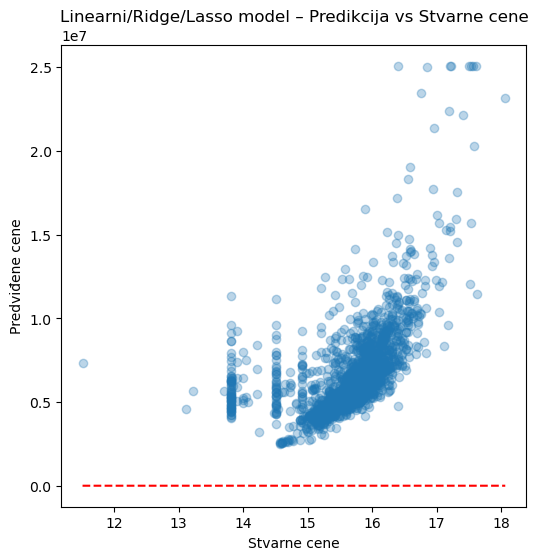

In [221]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")  # idealna linija
plt.xlabel("Stvarne cene")
plt.ylabel("Predviđene cene")
plt.title("Linearni/Ridge/Lasso model – Predikcija vs Stvarne cene")
plt.show()

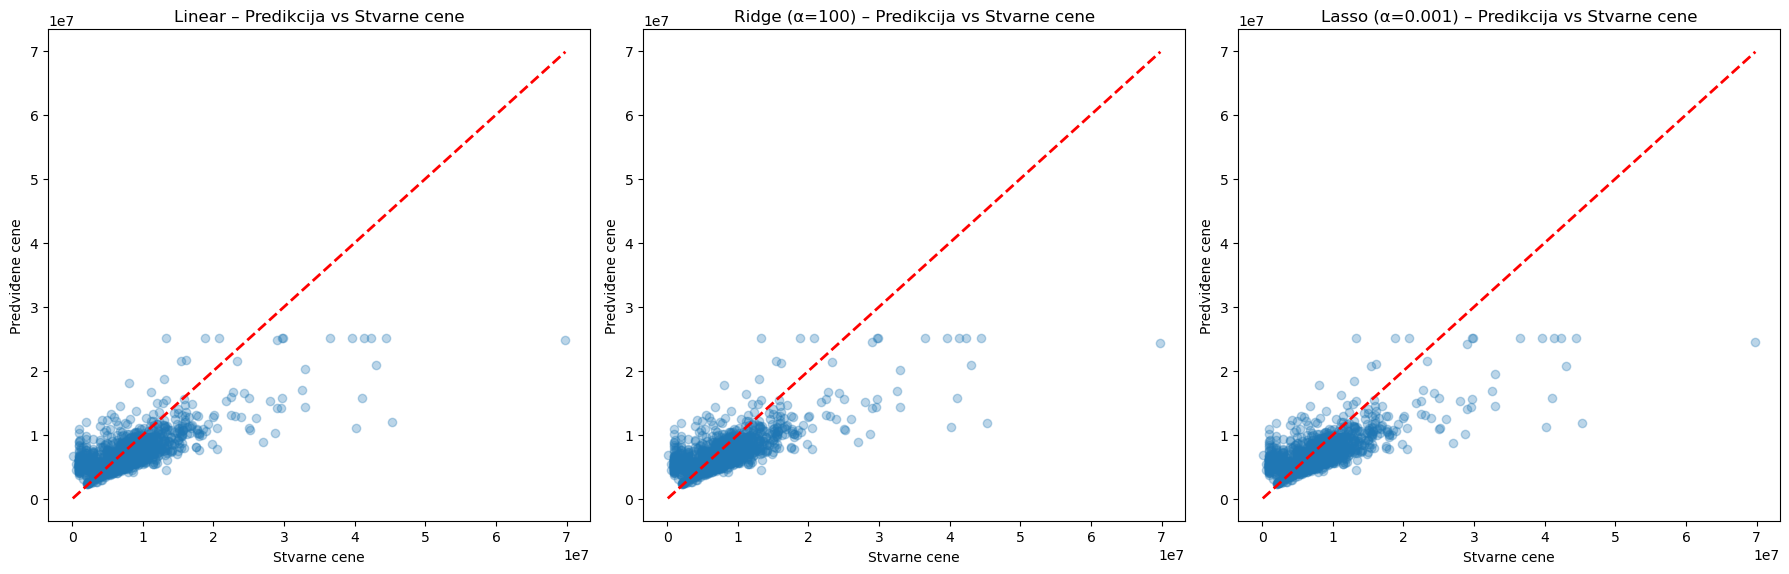

In [223]:
models = {
    "Linear": LinearRegression(),
    "Ridge (α=100)": Ridge(alpha=100, random_state=42),
    "Lasso (α=0.001)": Lasso(alpha=0.001, random_state=42, max_iter=10000)
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, models.items()):
    pipeline = Pipeline(steps=[
        ("preprocessor", numeric_preprocessor_hybrid2),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    lower, upper = np.percentile(y_train, [1, 99]) 
    y_pred_clipped = np.clip(y_pred, lower, upper)
    y_pred = unlog(y_pred_clipped)
    y_test_unlog = unlog(y_test)

    ax.scatter(y_test_unlog, y_pred, alpha=0.3)
    ax.plot([y_test_unlog.min(), y_test_unlog.max()], [y_test_unlog.min(), y_test_unlog.max()],
            "r--", lw=2)
    ax.set_title(f"{name} – Predikcija vs Stvarne cene")
    ax.set_xlabel("Stvarne cene")
    ax.set_ylabel("Predviđene cene")

plt.tight_layout()
plt.show()


R² je negativan – jer model u proseku promašuje gore nego što bi prosek pogodio.

RMSLE izgleda bolje – jer RMSLE ublažava uticaj outliera (log transformacija).

Graf pokazuje da model radi za većinu tipičnih primera, ali outlieri ga razbijaju.

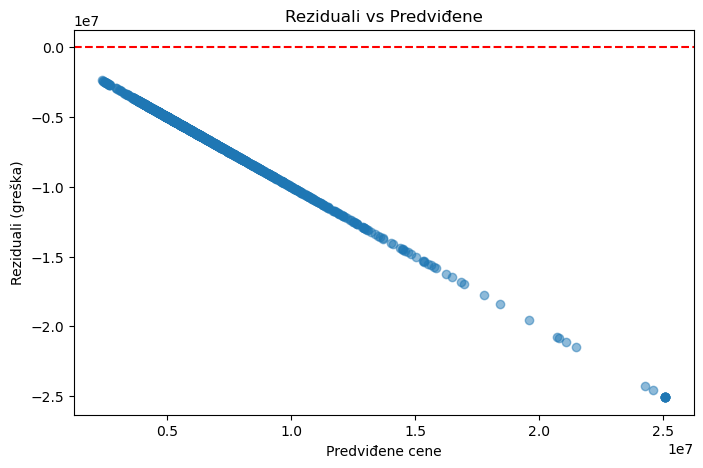

In [225]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predviđene cene")
plt.ylabel("Reziduali (greška)")
plt.title("Reziduali vs Predviđene")
plt.show()

Reziduali vs Predviđene

Idealno: tačke treba da budu nasumično raspoređene oko crvene linije (0).

Kod tebe: vidimo jak bias i outliere → model sistematski promašuje i podcenjuje ili precenjuje cene. To je znak da linearni model nije dovoljno fleksibilan.

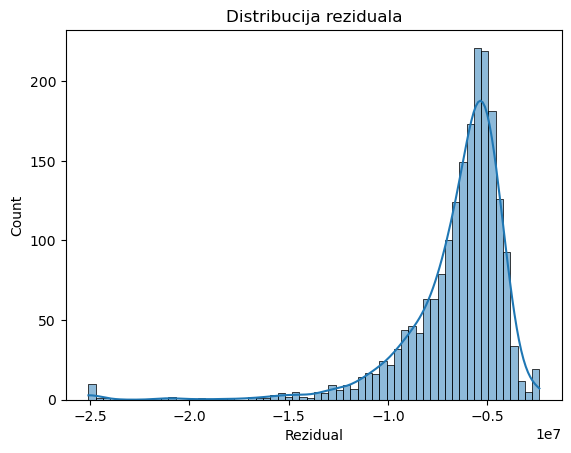

In [227]:
sns.histplot(residuals, kde=True)
plt.xlabel("Rezidual")
plt.title("Distribucija reziduala")
plt.show()

Idealno: simetrična i zvonasta (oko 0).

Kod tebe: jako leva asimetrija (dosta negativnih grešaka). To znači da ima puno slučajeva gde model jako podcenjuje cenu.

Ovo ti lepo objašnjava zašto je R² negativan – model je gori od naivnog predviđanja prosečne vrednosti.

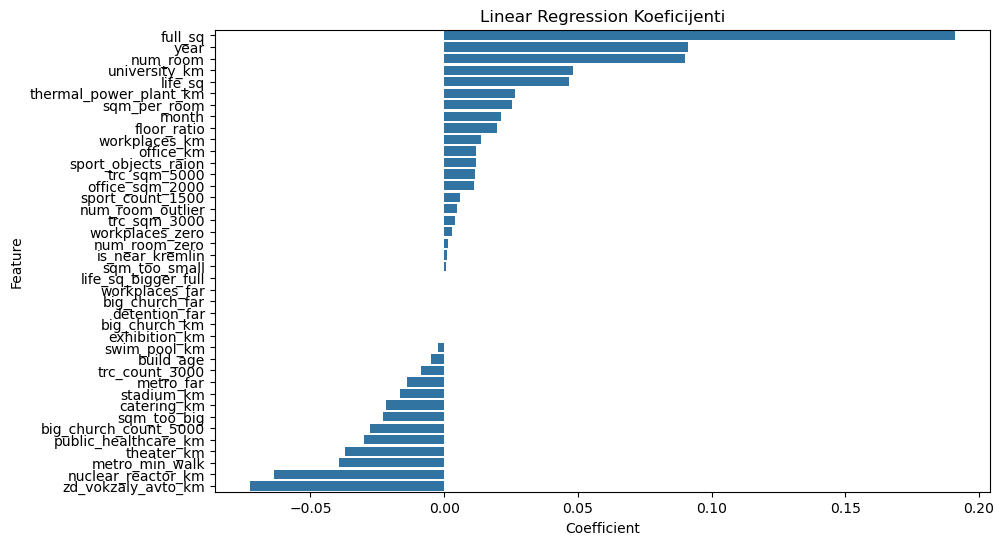

In [229]:
coefs = pipeline.named_steps["model"].coef_
features = pipeline.named_steps["preprocessor"].get_feature_names_out()

coef_df = pd.DataFrame({"Feature": features, "Coefficient": coefs})
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Linear Regression Koeficijenti")
plt.show()

Koeficijenti linearne regresije

Daje interpretabilnost: npr. full_sq, num_room, life_sq pozitivno utiču, dok udaljenost od nuclear_reactor_km, zd_vokzaly_avto_km negativno utiče.

Ovo je korisno za razumevanje šta model gleda, ali ne znači da daje dobre predikcije.

In [263]:
num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

pipeline = Pipeline(steps=[
    ("preprocessor", num_preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}


grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring=rmsle_scorer,
    n_jobs=-1,
    verbose=2
)


grid.fit(X_train, y_train)

print("Najbolji parametri:", grid.best_params_)
print("Najbolji score (RMSLE):", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

print("Evaluacija na test setu:")
evaluate_regression(y_test_unlog, y_pred)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Najbolji parametri: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Najbolji score (RMSLE): -0.029509154931596046


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Evaluacija na test setu:
MSE:  9280032075166.867
RMSE:  3046314.506935695
MAE:  1746591.0974404141
R²:  0.5940116797990738
RMSLE:  0.47231333578510476


{'MSE': 9280032075166.867,
 'RMSE': 3046314.506935695,
 'MAE': 1746591.0974404141,
 'R²': 0.5940116797990738,
 'RMSLE': 0.47231333578510476}

In [267]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor), 
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])


param_dist = {
    "model__n_estimators": randint(100, 1000),        
    "model__max_depth": [10, 20, 30, None],           
    "model__min_samples_split": randint(2, 20),     
    "model__min_samples_leaf": randint(1, 10),      
    "model__max_features": ["sqrt", "log2", None]    
}

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,             
    cv=3,                  
    scoring=rmsle_scorer,   
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit
rand_search.fit(X_train, y_train)

print("Najbolji parametri:", rand_search.best_params_)
print("Najbolji score (RMSLE):", rand_search.best_score_)

# Finalna evaluacija na test setu
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

print("Evaluacija na test setu:")
evaluate_regression(y_test_unlog, y_pred)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najbolji parametri: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 6, 'model__n_estimators': 506}
Najbolji score (RMSLE): -0.02941958511833113


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Evaluacija na test setu:
MSE:  9440846550003.924
RMSE:  3072596.0603378904
MAE:  1753827.596471535
R²:  0.5869762732429042
RMSLE:  0.4729097128764941


{'MSE': 9440846550003.924,
 'RMSE': 3072596.0603378904,
 'MAE': 1753827.596471535,
 'R²': 0.5869762732429042,
 'RMSLE': 0.4729097128764941}

In [269]:
print(len(rand_search.best_estimator_.named_steps["model"].feature_importances_))

39


In [271]:
len(X_train.columns)

55

39 39 True


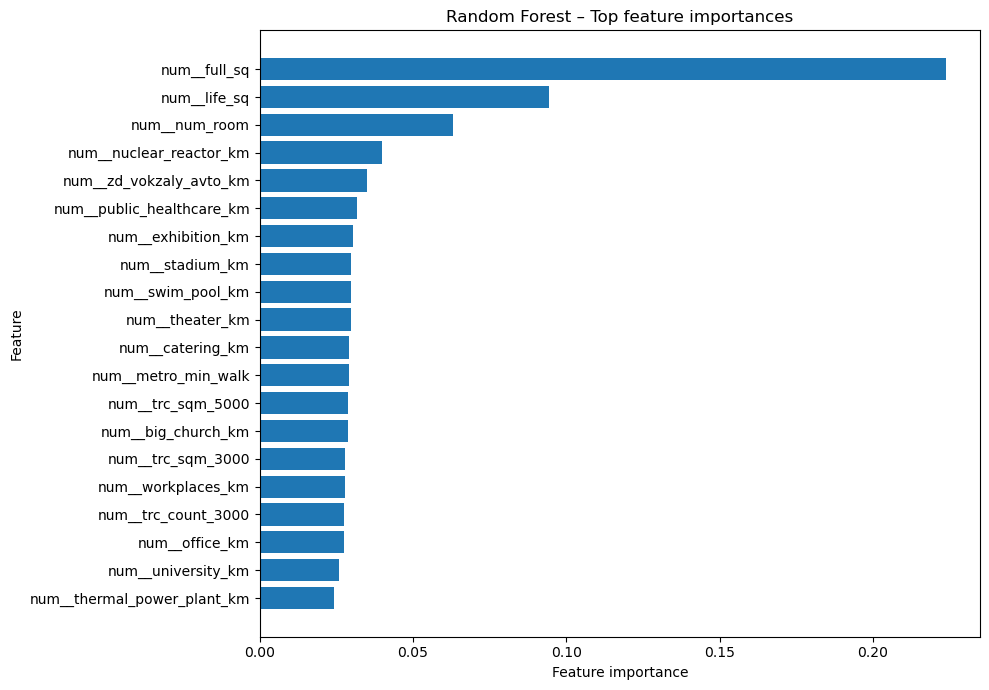

In [273]:
best_pipe = rand_search.best_estimator_
preproc   = best_pipe.named_steps["preprocessor"]
rf        = best_pipe.named_steps["model"]

names = preproc.get_feature_names_out()
imps  = rf.feature_importances_

print(len(names), len(imps), np.isclose(imps.sum(), 1.0))

feat_df = (pd.DataFrame({"Feature": names, "Importance": imps})
           .sort_values("Importance", ascending=False))

TOPN = 20
plt.figure(figsize=(10,7))
plt.barh(feat_df["Feature"].head(TOPN)[::-1], feat_df["Importance"].head(TOPN)[::-1])
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest – Top feature importances")
plt.tight_layout()
plt.show()

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


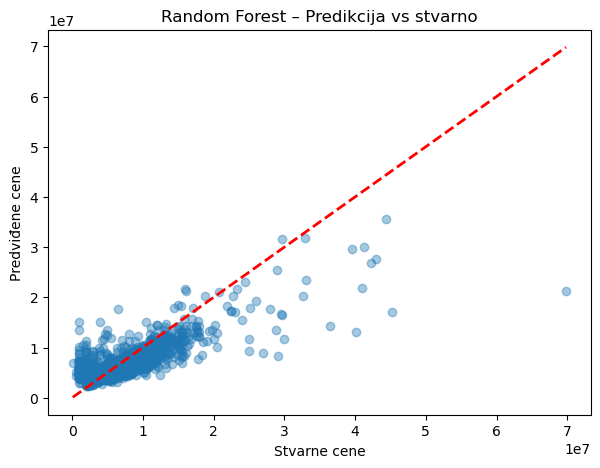

In [275]:
pipe_best = rand_search.best_estimator_

y_pred_log = pipe_best.predict(X_test)
y_pred = unlog(y_pred_log)
y_true = unlog(y_test)

import numpy as np, matplotlib.pyplot as plt
plt.figure(figsize=(7,5))
plt.scatter(y_true, y_pred, alpha=0.4)
m = [np.min([y_true, y_pred]), np.max([y_true, y_pred])]
plt.plot(m, m, "r--", lw=2)        # idealna linija y=x
plt.xlabel("Stvarne cene"); plt.ylabel("Predviđene cene")
plt.title("Random Forest – Predikcija vs stvarno")
plt.show()

Predikcija vs stvarne cene (ŷ naspram y)

Isprekidana linija je savršena pogodivost (ŷ = y).

Tačke su uglavnom ispod linije za skupe stanove → model sistematski potcenjuje visoke cene.

U nižem cenovnom rangu rasipanje je manje, pa tu pogadja bolje.
    
Bias: downward bias na „skupom repu“. Pomaže log-target, robustniji modeli i bolja obrada outliera.

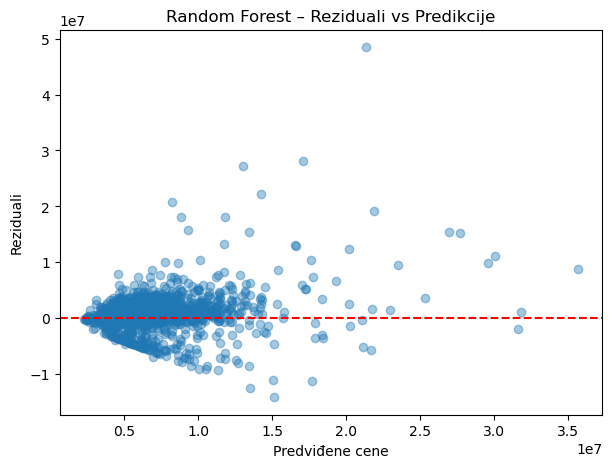

In [277]:
resid = y_true - y_pred
plt.figure(figsize=(7,5))
plt.scatter(y_pred, resid, alpha=0.4)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predviđene cene"); plt.ylabel("Reziduali")
plt.title("Random Forest – Reziduali vs Predikcije")
plt.show()


Reziduali vs predikcije (r = y − ŷ naspram ŷ)

Oblik „levka“: varijansa reziduala raste sa predikcijom (heteroskedastičnost).

Mnogi pozitivni reziduali pri većim ŷ → potcenjivanje kada su cene visoke.
    
Dodatna obrada outliera, još feature-a koji objašnjavaju luksuz/centar, i/ili modeli koji bolje hvataju nelinearnosti.

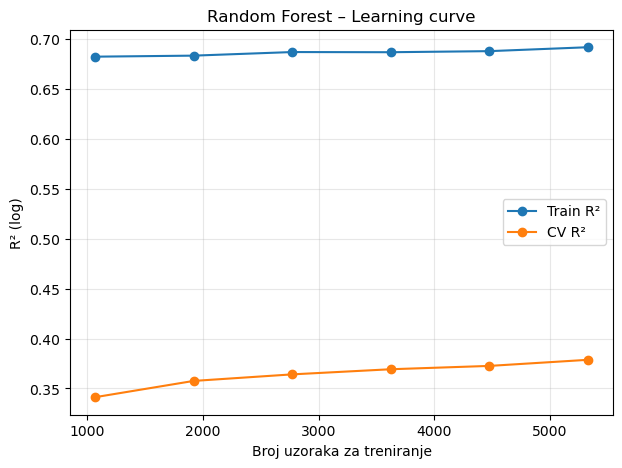

In [279]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe_best, X_train, y_train,
    cv=3, scoring="r2",  # R² u log skali
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1, shuffle=True, random_state=42
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
plt.title("Random Forest – Learning curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

Learning curve (R² na log-targetu)

Train R² visoko (0.74) i stabilno; CV R² znatno niži (0.40) ali raste sa više uzoraka.

Jasna varijanca (overfitting): model uči, ali bi mu koristilo još podataka i/ili jača regularizacija.
    
Probaj veći min_samples_leaf / min_samples_split, limit depth, više podataka ili ensembling (GBM/LightGBM/CatBoost).

In [283]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),
    ("model", RandomForestRegressor(
        random_state=42, 
        n_jobs=-1,
        max_depth=6,
        max_features='sqrt',
        min_samples_leaf=10,
        min_samples_split=5
    ))
])

pipe.fit(X_train,y_train)


r2_train = r2_score(y_train, pipe.predict(X_train))
r2_test  = r2_score(y_test, pipe.predict(X_test))

print(f"Train R²: {r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f}")

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


Train R²: 0.3824
Test  R²: 0.3426


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


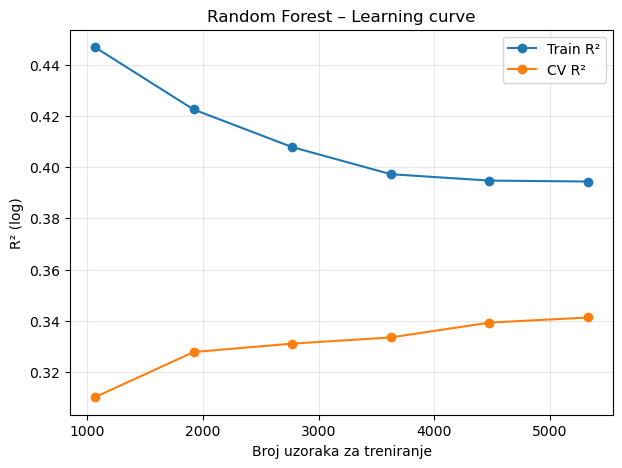

In [285]:
train_sizes, train_scores, val_scores = learning_curve(
    pipe, X_train, y_train,
    cv=3, scoring="r2",  # R² u log skali
    train_sizes=np.linspace(0.2, 1.0, 6),
    n_jobs=-1, shuffle=True, random_state=42
)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train R²")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV R²")
plt.xlabel("Broj uzoraka za treniranje"); plt.ylabel("R² (log)")
plt.title("Random Forest – Learning curve")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [289]:
y_pred = pipe.predict(X_test)

y_pred = unlog(y_pred)
y_unloged = unlog(y_test)

evaluate_regression(y_unloged,y_pred)

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


MSE:  11825459085078.262
RMSE:  3438816.5239044465
MAE:  1976209.8701829638
R²:  0.4826528366854401
RMSLE:  0.4894893393938465


{'MSE': 11825459085078.262,
 'RMSE': 3438816.5239044465,
 'MAE': 1976209.8701829638,
 'R²': 0.4826528366854401,
 'RMSLE': 0.4894893393938465}

In [291]:
pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor),  
    ("model", xgb.XGBRegressor(
        objective="reg:squarederror",  
        tree_method="hist",            
        random_state=42,
        n_jobs=-1
    ))
])


param_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [3, 6, 9, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}



rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring=rmsle_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)


rand_search.fit(X_train, y_train)

print("Najbolji parametri:", rand_search.best_params_)
print("Najbolji RMSLE score:", rand_search.best_score_)

best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

y_pred = unlog(y_pred)
y_test_unlog = unlog(y_test)

evaluate_regression(y_test_unlog, y_pred) 

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Najbolji parametri: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}
Najbolji RMSLE score: -0.0294196193520523
MSE:  7995001509996.838
RMSE:  2827543.370135432
MAE:  1764686.8509759754
R²:  0.6502299553755453
RMSLE:  0.47139650412500617


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


{'MSE': 7995001509996.838,
 'RMSE': 2827543.370135432,
 'MAE': 1764686.8509759754,
 'R²': 0.6502299553755453,
 'RMSLE': 0.47139650412500617}

In [293]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor), 
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror", 
    tree_method="hist",       
    random_state=42,
    n_jobs=-1,
   
    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = cross_val_predict(pipe, X_train, y_train, cv=cv, n_jobs=-1)

In [307]:
evaluate_regression(y_train, oof_preds)

MSE:  0.22354247843114197
RMSE:  0.4728027902108256
MAE:  0.2871791700249696
R²:  0.38124023779114125
RMSLE:  0.029381690409125992


{'MSE': 0.22354247843114197,
 'RMSE': 0.4728027902108256,
 'MAE': 0.2871791700249696,
 'R²': 0.38124023779114125,
 'RMSLE': 0.029381690409125992}

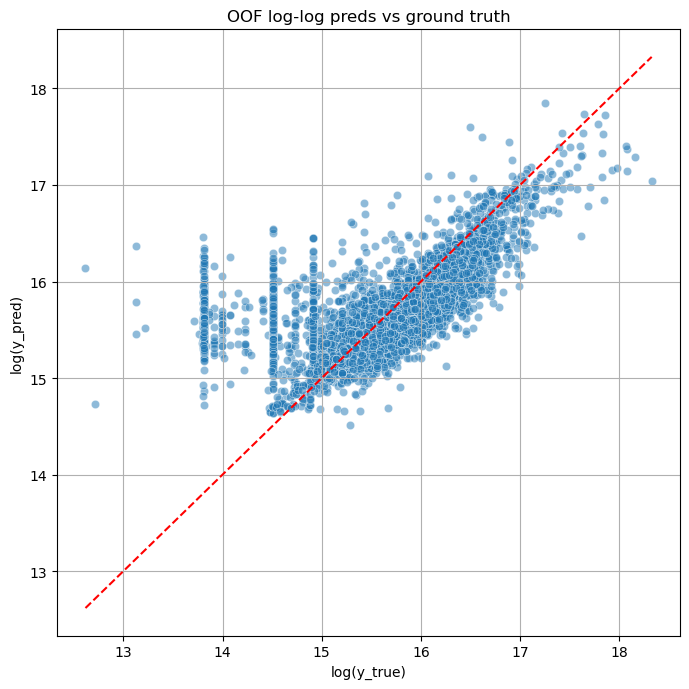

In [295]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_train, y=oof_preds, alpha=0.5)
plt.xlabel("log(y_true)")
plt.ylabel("log(y_pred)")
plt.title("OOF log-log preds vs ground truth")
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         linestyle='--', color='red')  
plt.grid()
plt.tight_layout()
plt.show()


In [309]:
param_dist = {
    "model__n_estimators": [300, 600, 900],
    "model__max_depth": [3, 6, 9, 12],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.3],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

rand_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring=rmsle_scorer,
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

rand_search.fit(X_train, y_train)
best_model = rand_search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [321]:
y_pred = best_model.predict(X_test)

y_pred = np.expm1(y_pred)
y_true = np.expm1(y_test)

print("RMSLE:", rmsle(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2:", r2_score(y_true, y_pred))


RMSLE: 0.47139650412500617
RMSE: 2827543.370135432
R2: 0.6502299553755453


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


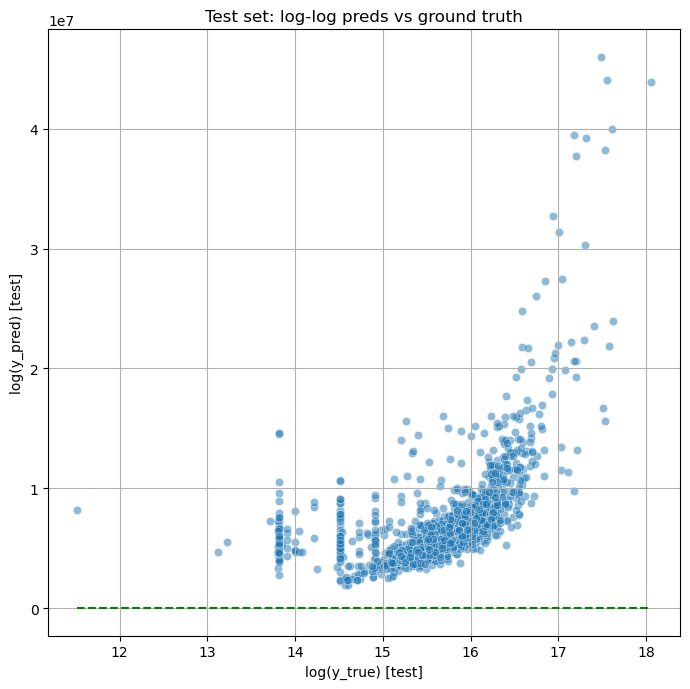

In [323]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.xlabel("log(y_true) [test]")
plt.ylabel("log(y_pred) [test]")
plt.title("Test set: log-log preds vs ground truth")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='green')  
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
print(y_pred)

In [233]:
base_estimators = [
    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42
    )),
    ("lgb", LGBMRegressor(
        objective="regression",
        boosting_type="gbdt",
        n_jobs=-1,
        random_state=42
    )),
    ("ridge", RidgeCV(alphas=(0.1, 1.0, 10.0)))
]
final_estimator = RidgeCV(alphas=(0.1, 1.0, 10.0))


In [ ]:
df["price_doc_log"].head()

In [235]:
stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=final_estimator,
    passthrough=True,  
    n_jobs=-1,
    cv=5
)

preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])


In [243]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=RidgeCV()
)

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("stacking", stacking_model)
])

model_pipeline.fit(X_train, y_train)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007309 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4951
[LightGBM] [Info] Number of data points in the train set: 7992, number of used features: 39
[LightGBM] [Info] Start training from score 15.626074
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4924
[LightGBM] [Info] Number of data points in the train set: 6393, number of used features: 39
[LightGBM] [Info] Start training from score 15.626280


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4913
[LightGBM] [Info] Number of data points in the train set: 6393, number of used features: 39
[LightGBM] [Info] Start training from score 15.624861


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4927
[LightGBM] [Info] Number of data points in the train set: 6394, number of used features: 39
[LightGBM] [Info] Start training from score 15.628512


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4915
[LightGBM] [Info] Number of data points in the train set: 6394, number of used features: 39
[LightGBM] [Info] Start training from score 15.623685


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4928
[LightGBM] [Info] Number of data points in the train set: 6394, number of used features: 39
[LightGBM] [Info] Start training from score 15.627031


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,steps,"[('preprocessor', ...), ('stacking', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('quantile', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [245]:
meta = model_pipeline.named_steps["stacking"].final_estimator_
print(meta)

RidgeCV()


In [247]:
print(model_pipeline.named_steps["stacking"].final_estimator_.coef_)

[0.04120728 0.54716825 0.41030822]


In [255]:
y_pred = model_pipeline.predict(X_test)
evaluate_regression(unlog(y_test),unlog(y_pred))

MSE:  8450273434490.311
RMSE:  2906935.402531386
MAE:  1733285.3678861489
R²:  0.6303124505261427
RMSLE:  0.46853051459898254


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MSE': 8450273434490.311,
 'RMSE': 2906935.402531386,
 'MAE': 1733285.3678861489,
 'R²': 0.6303124505261427,
 'RMSLE': 0.46853051459898254}

In [249]:
X_train, X_test, y_train, y_test = return_train_test(df_hybrid3)

price = unlog(y_train)     
w = 1 / np.sqrt(price)

num_preprocessor = create_preprocessor(nominal_cols, ordinal_cols, freq_cols, hight_corr_cols)

pipe = Pipeline(steps=[
    ("preprocessor", num_preprocessor), 
    ("model", xgb.XGBRegressor(
    objective="reg:squarederror",  
    tree_method="hist",          
    random_state=42,
    n_jobs=-1,

    subsample=0.8,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=1.0
    ))
])

pipe.fit(
    X_train, 
    y_train,
    model__sample_weight=w
)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('preprocess', ...), ('quantile', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nominal', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [251]:
evaluate_regression(unlog(y_test), y_pred)

MSE:  11148033333211.363
RMSE:  3338867.0733066574
MAE:  1971011.956860903
R²:  0.5122892582876086
RMSLE:  0.4849592402261638


{'MSE': 11148033333211.363,
 'RMSE': 3338867.0733066574,
 'MAE': 1971011.956860903,
 'R²': 0.5122892582876086,
 'RMSLE': 0.4849592402261638}

In [257]:
# === Target 1: log(price_doc) ===
df1 = df_hybrid3.copy()
df1 = df1[df1["price_doc"].notna() & df1["full_sq"].notna()]

df1["y_log_price"] = np.log(df1["price_doc"])

X1 = df1.drop(columns=["price_doc", "y_log_price"])
y1 = df1["y_log_price"]

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

pipe.fit(X1_train, y1_train)
y1_pred = pipe.predict(X1_test)

rmsle_price = np.sqrt(mean_squared_log_error(np.exp(y1_test), np.exp(y1_pred)))
print("RMSLE (log price_doc):", rmsle_price)


# === Target 2: log(price_per_m2) ===
df2 = df_hybrid3.copy()
df2 = df2[df2["price_doc"].notna() & df2["full_sq"].notna() & (df2["full_sq"] > 0)]

df2["price_per_m2"] = df2["price_doc"] / df2["full_sq"]
df2["y_log_price_m2"] = np.log(df2["price_per_m2"])

X2 = df2.drop(columns=["price_doc", "price_per_m2", "y_log_price_m2"])
y2 = df2["y_log_price_m2"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

pipe.fit(X2_train, y2_train)
y2_pred = pipe.predict(X2_test)

C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


RMSLE (log price_doc): 0.4713965399736251


C:\Users\aleks\anaconda3\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [259]:
evaluate_regression(unlog(y1_test),unlog(y1_pred))

MSE:  7995011316667.251
RMSE:  2827545.1042675255
MAE:  1764689.0255255252
R²:  0.6502295263475407
RMSLE:  0.47139674208510995


{'MSE': 7995011316667.251,
 'RMSE': 2827545.1042675255,
 'MAE': 1764689.0255255252,
 'R²': 0.6502295263475407,
 'RMSLE': 0.47139674208510995}

In [261]:
evaluate_regression(unlog(y2_test),unlog(y2_pred))

MSE:  2077266000.3762703
RMSE:  45577.03369435389
MAE:  32010.412897974544
R²:  0.31366497149432737
RMSLE:  0.46954304688065934


{'MSE': 2077266000.3762703,
 'RMSE': 45577.03369435389,
 'MAE': 32010.412897974544,
 'R²': 0.31366497149432737,
 'RMSLE': 0.46954304688065934}